#### varaibles
- real gdp per capita growth - trend + cycle of real values? diff og gdp real per capita
- inflation = inflation trend + measurement errors???
- short rate = inflation trend + real rate trend 
- long rate = inflation trend + real rate trend + term trend
- inflation expectations??
- growth expextations??
- 

In [1]:
import Pkg
Pkg.activate("../")

using Revise

includet("../src/TCVAR/TCVAR.jl")

  Activating project at `~/projects/MacroFinanceScenarios`


In [2]:
using .TCVAR
using DataFrames, XLSX, TimeSeries
using StatsBase
using LinearAlgebra
using Plots


In [3]:
df = DataFrame(XLSX.readtable("../data/DelNegro.xlsx", "Sheet1"))
allowmissing!(df)

df[df.Date .>= Date(2008, 10, 1), :BILL] .= missing

data = TimeArray(df[!,[:Date, :Pi, :EPi, :BILL, :EBILL, :TBlong]]; timestamp = :Date)
presample, data = data[Date(1954,01,01):Date(1959,12,31)], data[Date(1960,01,01):Date(2016,12,31)]

display(presample)
display(data) 

24×5 TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 1954-01-01 to 1959-10-01
┌────────────┬──────────┬─────────┬──────┬─────────┬────────┐
│            │ Pi       │ EPi     │ BILL │ EBILL   │ TBlong │
├────────────┼──────────┼─────────┼──────┼─────────┼────────┤
│ 1954-01-01 │  2.01108 │ missing │ 1.06 │ missing │   2.71 │
│ 1954-04-01 │ -0.55724 │ missing │ 0.79 │ missing │   2.63 │
│ 1954-07-01 │ -1.31896 │ missing │ 0.88 │ missing │   2.58 │
│ 1954-10-01 │ -0.38172 │ missing │ 1.02 │ missing │   2.64 │
│ 1955-01-01 │   1.3246 │ missing │ 1.22 │ missing │   2.81 │
│ 1955-04-01 │  0.40624 │ missing │ 1.48 │ missing │   2.86 │
│ 1955-07-01 │  1.59788 │ missing │ 1.86 │ missing │   2.98 │
│ 1955-10-01 │  1.11152 │ missing │ 2.34 │ missing │   2.95 │
│ 1956-01-01 │  1.63748 │ missing │ 2.33 │ missing │   2.95 │
│ 1956-04-01 │  2.70964 │ missing │ 2.57 │ missing │   3.07 │
│ 1956-07-01 │  3.91252 │ missing │ 2.58 │ missing │   3.19 │
│     ⋮      │    ⋮     │

228×5 TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 1960-01-01 to 2016-10-01
┌────────────┬──────────┬────────┬─────────┬─────────┬────────┐
│            │ Pi       │ EPi    │ BILL    │ EBILL   │ TBlong │
├────────────┼──────────┼────────┼─────────┼─────────┼────────┤
│ 1960-01-01 │  0.52872 │ 1.6827 │    3.87 │ missing │   4.28 │
│ 1960-04-01 │  2.11204 │ 1.6827 │    2.99 │ missing │   4.16 │
│ 1960-07-01 │  1.53004 │ 1.6827 │    2.36 │ missing │   3.87 │
│ 1960-10-01 │  1.77444 │ 1.6827 │    2.31 │ missing │   3.93 │
│ 1961-01-01 │   0.7474 │ 1.6827 │    2.35 │ missing │   3.85 │
│ 1961-04-01 │  -0.0452 │ 1.6827 │     2.3 │ missing │   3.81 │
│ 1961-07-01 │   1.4696 │ 1.6827 │     2.3 │ missing │    4.0 │
│ 1961-10-01 │  0.45052 │ 1.6827 │    2.46 │ missing │   4.03 │
│ 1962-01-01 │  1.77756 │ 1.6827 │    2.72 │ missing │   4.09 │
│ 1962-04-01 │  1.38888 │ 1.6827 │    2.72 │ missing │   3.94 │
│ 1962-07-01 │  1.04924 │ 1.6827 │    2.84 │ missing │   4.0

In [4]:
n = 5 #number of observatin variables
nt = 3 #number of trends
p=4

# Minnesota prior for the cycle VAR (mean-zero cycle => white-noise prior, δ = 0).
# ψ is the prior scale of diag(Σc); with d = n+2 it equals the prior mean of diag(Σc).
cycle_prior = MinnesotaPrior(.2, n, p, [2., 1., 1., .5, 1.], n + 2; δ = zeros(n))

# prior mean of the cycle covariance, used for initial states / simulation below
cycle_covariance_mean = Matrix(cycle_prior.Ψ) / (cycle_prior.d - n - 1)

priors = (
        initial_trend_mean = [2., .5, 1.],
        initial_cycle_mean = zeros(n),
        initial_trend_covariance = diagm(fill(1,nt)),
        trend_covariance_df = 100,
        trend_covariance_mean = diagm([2., 1., 1.].^2 ./ 400),
        )


(initial_trend_mean = [2.0, 0.5, 1.0], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 0; 0 1 0; 0 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.01 0.0 0.0; 0.0 0.0025 0.0; 0.0 0.0 0.0025])

In [5]:
n_trends = 3
n_variables = 5
initial_state_covariance = [priors.initial_trend_covariance zeros(n_trends, n_variables)
                            zeros(n_variables, n_trends) cycle_covariance_mean]


8×8 Matrix{Float64}:
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  2.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.5  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0

In [7]:
priors.trend_covariance_mean

3×3 Matrix{Float64}:
 0.01  0.0     0.0
 0.0   0.0025  0.0
 0.0   0.0     0.0025

In [8]:
observation_trend_mapping  = [1 0 0  
                              1 0 0  
                              1 1 0  
                              1 1 0  
                              1 1 1 ]



trend_states_samples, cycle_states_samples, trend_covariance_samples, betas_samples, sigmas_samples = TCVAR.gibbs_sampler(values(data), observation_trend_mapping, priors, cycle_prior; burnin = 1_500, n_samples = 1_500, thin=5, logging=false)

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.68)  
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95) 

LoadError: DimensionMismatch: tried to assign 229×3 array to 1×228×3 destination

In [7]:
show(err)


1-element ExceptionStack:
LoadError: DimensionMismatch: tried to assign 229×3 array to 1×228×3 destination
Stacktrace:
 [1] throw_setindex_mismatch(X::Matrix{Float64}, I::Tuple{Int64, Int64, Int64})
   @ Base ./indices.jl:208
 [2] setindex_shape_check(::Matrix{Float64}, ::Int64, ::Int64, ::Int64)
   @ Base ./indices.jl:246
 [3] macro expansion
   @ ./multidimensional.jl:1017 [inlined]
 [4] _unsafe_setindex!(::IndexLinear, ::Array{Float64, 3}, ::Matrix{Float64}, ::Int64, ::Base.Slice{Base.OneTo{Int64}}, ::Base.Slice{Base.OneTo{Int64}})
   @ Base ./multidimensional.jl:1029
 [5] _setindex!
   @ ./multidimensional.jl:1008 [inlined]
 [6] setindex!
   @ ./abstractarray.jl:1443 [inlined]
 [7] gibbs_sampler(data::Matrix{Union{Missing, Float64}}, trend_mapping::Matrix{Int64}, priors::@NamedTuple{initial_trend_mean::Vector{Float64}, initial_cycle_mean::Vector{Float64}, initial_trend_covariance::Matrix{Int64}, trend_covariance_df::Int64, trend_covariance_mean::Matrix{Float64}}, cycle_prior::Minne

In [ ]:
priors.initial_trend_covariance

3×3 Matrix{Int64}:
 1  0  0
 0  1  0
 0  0  1

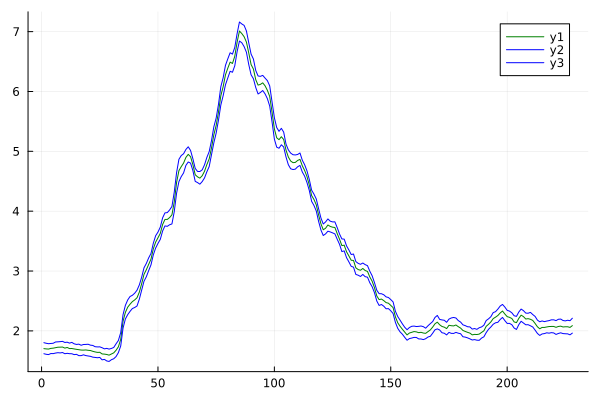

In [6]:
st = 1
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

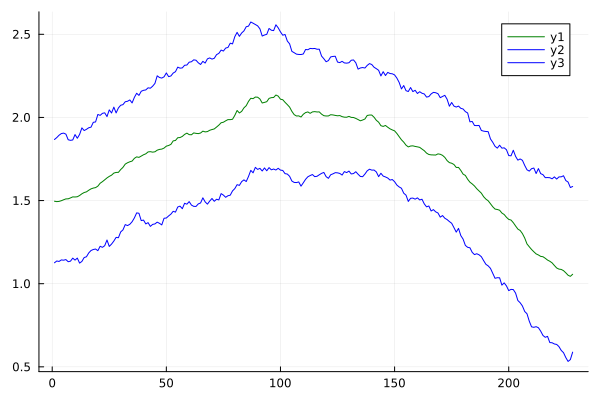

In [7]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

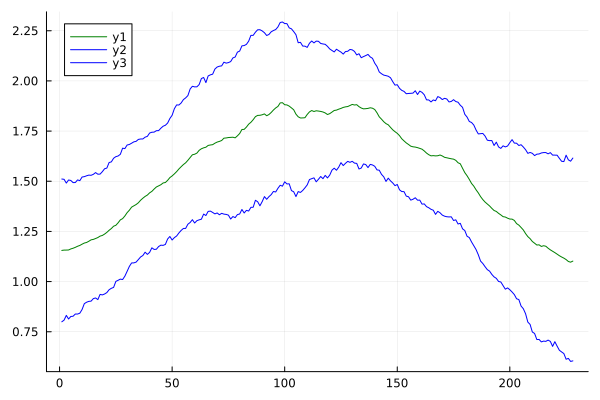

In [13]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

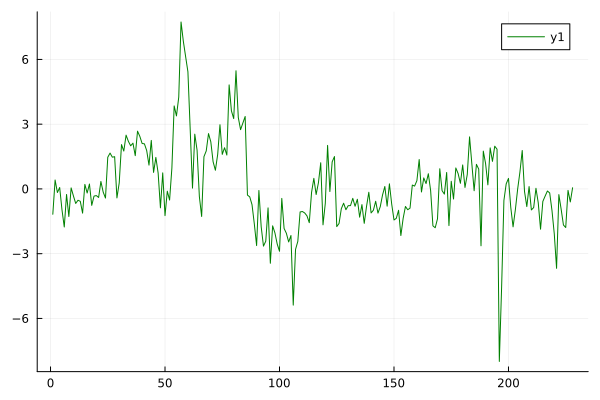

In [8]:
st=1
plot(cycle_states_mean[:,st], color="green" )

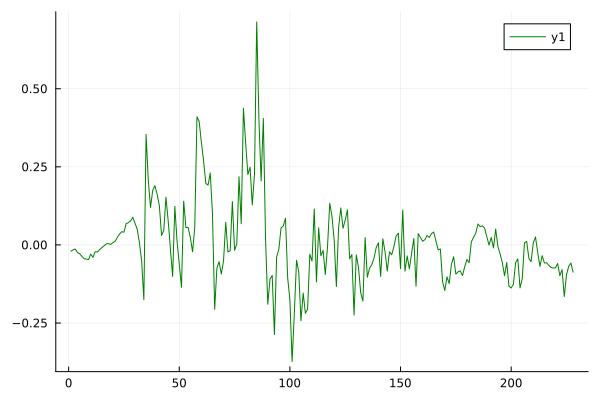

In [9]:
st=2
plot(cycle_states_mean[:,st], color="green" )

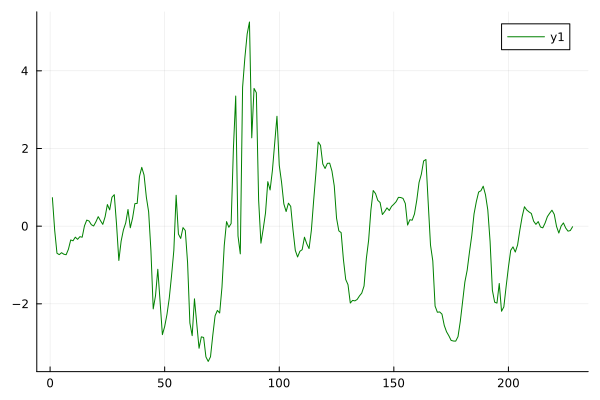

In [18]:
st=3
plot(cycle_states_mean[:,st], color="green" )

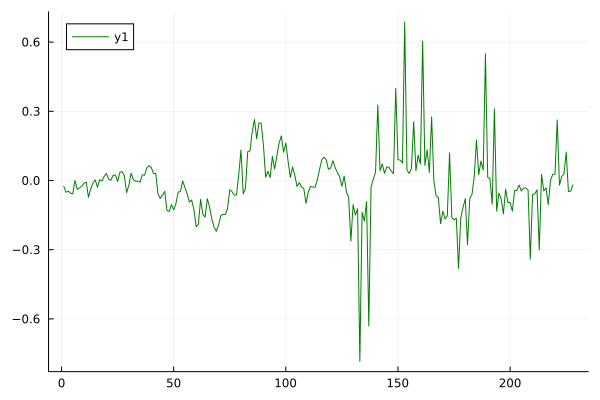

In [19]:
st=4
plot(cycle_states_mean[:,st], color="green" )

In [16]:
summarystats(trend_covariance_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

         Στ1    0.0127    0.0023    0.0009     7.3264    75.0294    1.1209     ⋯
         Στ2   -0.0002    0.0006    0.0000   198.5589   253.5239    1.0072     ⋯
         Στ3    0.0003    0.0008    0.0001    70.4580   359.2774    1.0183     ⋯
         Στ4   -0.0002    0.0006    0.0000   198.5589   253.5239    1.0072     ⋯
         Στ5    0.0028    0.0004    0.0000   291.6467   473.9927    0.9989     ⋯
         Στ6    0.0000    0.0003    0.0000   345.6931   392.3959    1.0014     ⋯
         Στ7    0.0003    0.0008    0.0001    70.4580   359.2774    1.0183     ⋯
         Στ8    0.0000    0.0003    0.0000   345.6931   392.3959    1.0014     ⋯
         Στ9    0.0029    0.0004    0.0000   304.3825   437.5122    1.0039     ⋯

                                                                1 column omitted


In [17]:
summarystats(betas_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

          β1    0.0078    0.0378    0.0019   379.4301   472.2365    0.9989     ⋯
          β2    0.0061    0.0686    0.0035   390.7196   388.2477    0.9994     ⋯
          β3   -0.0079    0.0576    0.0047   155.5229   346.2894    1.0069     ⋯
          β4   -0.0118    0.0897    0.0042   449.0158   418.5143    1.0035     ⋯
          β5   -0.0111    0.0610    0.0030   422.5621   419.2960    0.9998     ⋯
          β6    0.0899    0.0494    0.0020   578.5946   407.1390    1.0026     ⋯
          β7    0.0060    0.0901    0.0040   501.8473   461.1364    0.9990     ⋯
          β8    0.0004    0.0745    0.0035   460.9595   414.3835    1.0032     ⋯
          β9   -0.0291    0.1199    0.0069   301.5046   512.9479    0.9990     ⋯
         β10   -0.0353    0.0818    0.0042   375.2647   491.3931    1.0063     ⋯
       

In [18]:
summarystats(sigmas_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

         Σc1    1.8207    0.1980    0.0104   360.5257   472.2365    0.9990     ⋯
         Σc2    0.0365    0.0395    0.0040   102.3878   336.3859    1.0120     ⋯
         Σc3    0.2048    0.0945    0.0044   466.3737   515.1107    0.9993     ⋯
         Σc4    0.0917    0.1428    0.0264    32.0339    71.2938    1.0736     ⋯
         Σc5    0.1138    0.0533    0.0029   339.2518   429.5927    0.9997     ⋯
         Σc6    0.0365    0.0395    0.0040   102.3878   336.3859    1.0120     ⋯
         Σc7    0.1030    0.0159    0.0022    49.9382   121.2419    1.0189     ⋯
         Σc8    0.0241    0.0235    0.0020   137.4647   114.4426    1.0160     ⋯
         Σc9    0.0265    0.0263    0.0110     6.6032    28.6142    1.1487     ⋯
        Σc10    0.0249    0.0153    0.0014   132.3080   251.8897    1.0082     ⋯
       

In [23]:
plot(betas_samples)

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

LoadError: The backend must not support the series type Val{:density}, and there isn't a series recipe defined.

In [26]:
Σc = mean(sigmas_samples).nt.mean
Σc = reshape(Σc, n, n)
display(Σc)

β = mean(betas_samples).nt.mean
β = reshape(β, n, n*1)
display(β)

Στ = mean(trend_covariance_samples).nt.mean
Στ = reshape(Στ, nt, nt)
display(cov2cor(Στ))
display(diag(Στ) .^ .5)

5×5 Matrix{Float64}:
 1.79411      0.0424067     0.107201      0.00168398  0.120538
 0.0424067    0.280499     -0.000688154  -0.00238186  0.0390318
 0.107201    -0.000688154   0.709402      0.025241    0.100141
 0.00168398  -0.00238186    0.025241      0.853156    0.00845605
 0.120538     0.0390318     0.100141      0.00845605  0.475342

5×5 Matrix{Float64}:
  0.401899    -0.00832014   0.0429888  -0.0062348   -0.0359921
 -0.110923     0.712294     0.104339   -0.00848358   0.131948
  0.111276     0.00664144   0.825852    0.0432068    0.0519225
  0.00460987  -0.00433078   0.0367354   0.0277545    0.00855234
 -0.260648     0.0942786   -0.0249877   0.0138357    0.768959

3×3 Matrix{Float64}:
 1.0       0.151828  0.142649
 0.151828  1.0       0.120919
 0.142649  0.120919  1.0

3-element Vector{Float64}:
 0.15282605806088212
 0.057652243368346144
 0.0548315413071181

In [27]:
display(diag(Σc) .^ .5)

display(diag(Στ) .^ .5)

5-element Vector{Float64}:
 1.3394439805855263
 0.5296218035391672
 0.8422602583460558
 0.9236646804189055
 0.6894508021175776

3-element Vector{Float64}:
 0.15282605806088212
 0.057652243368346144
 0.0548315413071181

In [ ]:
model = tc_var(observation_tend_mapping, β, Στ, Σc, priors.initial_trend_mean, priors.initial_cycle_mean, priors.initial_trend_covariance, cycle_covariance_mean)

initial_states = [trend_states_mean[end,:]; cycle_states_mean[end,:]]

n_samples = 2_000
T = 100
states = zeros(n_samples, T, 8)

observations = zeros(n_samples, T, n)

for s in 1:2_000
    states[s, :, :], observations[s, :, :] = sample(model, initial_states, T)
end


UndefVarError: UndefVarError: `observation_tend_mapping` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations, (3, 2, 1))[[1,2],:,:] ./400
periods = [1, 5, 10, 25]
freq = 4
assets_names = ["GDP", "CPI"]
ret_in_years = cum_returns_in_periods(transformed_scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations[:,:,[3,4]] , (3, 2, 1))
freq = 4

transformed_scenarios = transformed_scenarios[:,freq:freq:end,:]

periods = [1, 5, 10, 25]


assets_names = ["ShortRate", "LongRate"]
ret_in_years = transformed_scenarios = transformed_scenarios[:,periods,:]
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
n_observations = size(model.T,1)
n_trends = 4
n_time_steps = size(data,1)
n_draws = 1000
trends_states = zeros(n_draws, n_time_steps, n_trends)

for s in 1:n_draws
    state_smoothed_samples = carter_kohn_sampler(model, values(data))
    trends_states[s,:,:] = state_smoothed_samples[:, 1:n_trends]
end

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95) 

UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.